# Options Risk Dashboard: Methodology

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alexeyklek10/Options_Risk_Dashboard/blob/main/notebooks/methodology.ipynb)

I use this notebook to walk through every piece of math the live [Options Risk Dashboard](https://github.com/alexeyklek10/Options_Risk_Dashboard) uses: the Black-Scholes pricer (Black & Scholes 1973, Merton 1973), the seven Greeks, the Manaster-Koehler / Newton-Raphson implied-vol solver, the volatility skew metrics, max-pain, gamma exposure under the SqueezeMetrics dealer sign convention, the Breeden-Litzenberger risk-neutral density, and the cross-source data validator. Each technique is introduced by name, citation, formula, code from `ord/`, then a one-paragraph interpretation of the output. A reader who finishes this notebook should be able to reproduce, audit, or extend every calculation in the dashboard.

The worked examples below run on a dated SPY chain snapshot (`notebooks/fixtures/spy_chain_2026_05_13.parquet`) so the outputs and screenshots in the README do not rot. The final cell shows how to re-run the same code path against today's live chain.

## 1. Setup

Install the package and the `py_vollib` reference oracle. The `_testcapi` shim is needed on CPython 3.11+ distributions that do not ship the private test module (notably the python.org Windows installer); `py_lets_be_rational` imports `DBL_MIN`/`DBL_MAX` from it, but those are simply `sys.float_info.min`/`.max`. See `tests/conftest.py` for the same shim.

In [1]:
# Colab / first-run install. Local runs from the cloned repo can skip this cell.
import importlib, sys
try:
    importlib.import_module('ord')
except ImportError:
    !pip install -q git+https://github.com/alexeyklek10/Options_Risk_Dashboard.git@main
    !pip install -q py_vollib

# Shim for py_vollib's _testcapi dependency.
import types
if '_testcapi' not in sys.modules:
    shim = types.ModuleType('_testcapi')
    shim.DBL_MIN = sys.float_info.min
    shim.DBL_MAX = sys.float_info.max
    sys.modules['_testcapi'] = shim


In [2]:
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc

from ord.pricing.black_scholes import bs_price
from ord.pricing.greeks import delta, gamma, vega, theta, rho, vanna, charm
from ord.pricing.iv_solver import implied_vol
from ord.analytics.iv_surface import interpolated_surface, observed_surface
from ord.analytics.skew import skew
from ord.analytics.max_pain import max_pain_all_expiries
from ord.analytics.gex import gamma_exposure
from ord.analytics.implied_pdf import implied_pdf_for_expiry

warnings.filterwarnings('ignore', category=FutureWarning)

plt.style.use('dark_background')
plt.rcParams['axes.facecolor'] = '#0E1117'
plt.rcParams['figure.facecolor'] = '#0E1117'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.2


## 2. The Black-Scholes model

Black & Scholes (1973) derived a closed-form price for European options under the no-arbitrage geometric Brownian motion model. Merton (1973) extended the derivation to underliers paying a continuous dividend yield $q$, which is the form used here (`ord.pricing.black_scholes.bs_price`). Define

$$d_1 = \frac{\ln(S/K) + (r - q + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}},\qquad d_2 = d_1 - \sigma\sqrt{T}.$$

The price of a European call $C$ and put $P$ is

$$C = S e^{-qT} N(d_1) - K e^{-rT} N(d_2), \qquad P = K e^{-rT} N(-d_2) - S e^{-qT} N(-d_1),$$

where $N(\cdot)$ is the standard normal CDF. The formulas are implemented from first principles in `ord/pricing/black_scholes.py`; `py_vollib` is **not** imported anywhere in the package's runtime code and lives in `requirements-dev.txt` solely as a reference oracle for the unit tests.

In [3]:
# Validate our hand-rolled pricer against py_vollib on a 1024-point Sobol grid
# over (S, K/S, T, r, sigma, q). Spec target: max absolute error < 1e-8.
from py_vollib.black_scholes_merton import black_scholes_merton

sampler = qmc.Sobol(d=6, scramble=True, seed=42)
samples = sampler.random_base2(m=10)  # 2**10 = 1024 points
lo = np.array([50.0, 0.5, 1/365, 0.0, 0.05, 0.0])
hi = np.array([500.0, 1.5, 2.0, 0.08, 1.0, 0.04])
grid = qmc.scale(samples, lo, hi)

max_err = {'call': 0.0, 'put': 0.0}
for option_type, flag in (('call', 'c'), ('put', 'p')):
    for row in grid:
        S, k_over_s, T, r, sigma, q = row
        K = float(S * k_over_s)
        ours = bs_price(float(S), K, float(T), float(r), float(sigma), option_type, float(q))
        theirs = black_scholes_merton(flag, float(S), K, float(T), float(r), float(sigma), float(q))
        max_err[option_type] = max(max_err[option_type], abs(ours - theirs))

print(f'Max absolute pricing error on 1024-point Sobol grid:')
print(f'  calls: {max_err["call"]:.3e}')
print(f'  puts : {max_err["put"]:.3e}')


C:\Users\alexe\AppData\Local\Temp\ipykernel_18260\2077501182.py:3: DeprecationWarning: py_vollib is deprecated and will be removed in a future release; please import from vollib instead.
  from py_vollib.black_scholes_merton import black_scholes_merton


Max absolute pricing error on 1024-point Sobol grid:
  calls: 1.705e-13
  puts : 1.705e-13


Both sides agree with `py_vollib.black_scholes_merton` to better than 1e-8 across the full hypercube, which covers the realistic equity-option parameter space ($50 \le S \le 500$, $0.5 \le K/S \le 1.5$, $T \in [1/365, 2]$, $r \in [0, 0.08]$, $\sigma \in [0.05, 1.0]$, $q \in [0, 0.04]$). The implementation is in `src/ord/pricing/black_scholes.py`; the same test is automated in `tests/pricing/test_black_scholes.py`.

## 3. Greeks: definitions, intuition, code

All seven Greeks are implemented in `ord/pricing/greeks.py`. The table below summarises each one's definition and the trader's intuition. Vanna and charm are reported in addition to the textbook five because they materially drive delta around earnings dates and after large spot moves; most retail platforms do not surface them at all.

| Greek | Definition | Intuition |
| --- | --- | --- |
| Delta | $\partial C / \partial S$ | Sensitivity of price to spot. |
| Gamma | $\partial^2 C / \partial S^2$ | How fast delta itself moves. |
| Vega  | $\partial C / \partial \sigma$ | Sensitivity to a vol level shift. |
| Theta | $\partial C / \partial T$ | Time decay per year (divide by 365 for daily). |
| Rho   | $\partial C / \partial r$ | Sensitivity to a parallel rate shift. |
| Vanna | $\partial^2 C / \partial S \partial \sigma$ | Delta's vol-sensitivity = vega's spot-sensitivity. |
| Charm | $\partial^2 C / \partial S \partial T$ | Delta drift over time. |

Vega is quoted **per 1.00 of $\sigma$** in this package (divide by 100 for the per-volatility-point convention most platforms display); theta is **per year**; rho is **per 1.00 of $r$**. The unit convention is documented in each function's docstring.

In [4]:
# Compare every Greek against py_vollib on a 256-point Sobol grid (smaller
# than the pricing grid to keep the notebook quick). Vanna and charm are
# validated by numerical differentiation since py_vollib does not expose them.
from py_vollib.black_scholes_merton.greeks.analytical import (
    delta as v_delta, gamma as v_gamma, vega as v_vega,
    theta as v_theta, rho as v_rho,
)

small = grid[:256]
errors = {g: 0.0 for g in ['delta', 'gamma', 'vega', 'theta', 'rho']}
for row in small:
    S, k_over_s, T, r, sigma, q = (float(x) for x in row)
    K = S * k_over_s
    errors['delta'] = max(errors['delta'], abs(delta(S, K, T, r, sigma, 'call', q) - v_delta('c', S, K, T, r, sigma, q)))
    errors['gamma'] = max(errors['gamma'], abs(gamma(S, K, T, r, sigma, q) - v_gamma('c', S, K, T, r, sigma, q)))
    errors['vega']  = max(errors['vega'],  abs(vega(S, K, T, r, sigma, q) - v_vega('c', S, K, T, r, sigma, q) * 100.0))
    errors['theta'] = max(errors['theta'], abs(theta(S, K, T, r, sigma, 'call', q) - v_theta('c', S, K, T, r, sigma, q) * 365.0))
    errors['rho']   = max(errors['rho'],   abs(rho(S, K, T, r, sigma, 'call', q) - v_rho('c', S, K, T, r, sigma, q) * 100.0))

print('Max abs error vs py_vollib (rescaled where conventions differ):')
for k, v in errors.items():
    print(f'  {k:6s}: {v:.3e}')


Max abs error vs py_vollib (rescaled where conventions differ):
  delta : 2.220e-16
  gamma : 1.388e-17
  vega  : 5.684e-14
  theta : 5.684e-14
  rho   : 8.527e-14


All five textbook Greeks agree with `py_vollib.black_scholes_merton` to better than $10^{-6}$ after rescaling for unit conventions. Vanna's closed form is

$$\text{vanna} = -e^{-qT}\,\phi(d_1)\,d_2 / \sigma,$$

which equals both $\partial \Delta / \partial \sigma$ and $\partial \text{vega} / \partial S$ by Schwarz's theorem. The unit test `tests/pricing/test_greeks.py::test_vanna_matches_numerical_diff` validates this against a central-difference numerical derivative with $h = 10^{-5}$.

## 4. The implied-volatility solver

Given an observed price $C^*$ we want the $\sigma$ that makes the model reproduce it. The solver in `ord/pricing/iv_solver.py` runs Newton-Raphson on vega, with the Manaster-Koehler (1982) closed-form initial guess

$$\sigma_0 = \sqrt{\frac{2}{T}\left|\ln(S/K) + r T\right|},$$

clamped to $[0.05, 2.0]$ to avoid degenerate starts at the money. Convergence is checked on the change in $\sigma$ rather than on the residual price -- in flat-vega regions (deep ITM with short T, deep OTM with low vol) a tiny price residual can coexist with a $\sigma$ very far from the true root, so a price-tolerance exit returns garbage. When Newton's step falls outside the bracket $[10^{-6}, 5.0]$ or vega drops below $10^{-10}$, the solver falls back to Brent's method on the same bracket. Prices outside the no-arb intrinsic bounds return `None`.

In [5]:
# Round-trip the Sobol grid: BS price -> implied_vol -> compare to input sigma.
max_err = 0.0
tested = 0
skipped_degenerate = 0
for row in grid:
    S, k_over_s, T, r, sigma_in, q = (float(x) for x in row)
    K = S * k_over_s
    if vega(S, K, T, r, sigma_in, q) < 1e-4:
        skipped_degenerate += 1
        continue
    price = bs_price(S, K, T, r, sigma_in, 'call', q)
    recovered = implied_vol(price, S, K, T, r, 'call', q)
    if recovered is None:
        continue
    tested += 1
    max_err = max(max_err, abs(recovered - sigma_in))
print(f'Tested {tested} cells; skipped {skipped_degenerate} where vega < 1e-4.')
print(f'Max abs round-trip error on sigma: {max_err:.3e}')


Tested 993 cells; skipped 31 where vega < 1e-4.
Max abs round-trip error on sigma: 4.038e-10


The solver recovers $\sigma$ to within $10^{-6}$ across every cell where the true vega exceeds $10^{-4}$ -- which is to say, every contract whose price moves enough as a function of vol for any solver to distinguish neighbouring $\sigma$ values to that tolerance. Deep ITM/OTM corners with very short T and very low vol genuinely cannot be inverted (the price curve as a function of $\sigma$ is locally flat to many decimal places) and we report `None` rather than returning a misleading number.

## 5. Worked example: SPY chain

Load the dated SPY chain fixture, recompute every IV from the mid via our solver, and build the volatility surface. The fixture is a SPY-like chain priced from first principles via Black-Scholes-Merton (see `.build_fixture.py` for the generator). It's structured to exercise every analytic with plausible numbers (downward-skewed smile, OI peaking at ATM with monthly cycles, asymmetric call/put OI mirroring SPY's typical positioning). The published README screenshots are generated from this same fixture so they never rot. The final cell of this notebook shows the one-line swap to re-run the same code path against today's live yfinance chain.

In [6]:
from pathlib import Path

FIXTURE_NAME = 'spy_chain_2026_05_13.parquet'
# Try the common locations: project root, notebooks/fixtures, notebook cwd.
CANDIDATES = [
    Path('notebooks/fixtures') / FIXTURE_NAME,
    Path('fixtures') / FIXTURE_NAME,
    Path(FIXTURE_NAME),
]
FIXTURE_PATH = next((p for p in CANDIDATES if p.exists()), None)

if FIXTURE_PATH is None:
    # Colab path: pull the fixture from the repo's raw URL.
    !wget -q https://raw.githubusercontent.com/alexeyklek10/Options_Risk_Dashboard/main/notebooks/fixtures/{FIXTURE_NAME} -O {FIXTURE_NAME}
    FIXTURE_PATH = Path(FIXTURE_NAME)

chain = pd.read_parquet(FIXTURE_PATH)
print(f'Loaded {len(chain)} rows across {chain["expiry"].nunique()} expiries.')
print(f'Underlying spot at snapshot: ${chain["underlying_price"].iloc[0]:.2f}')
chain.head()


Loaded 732 rows across 6 expiries.
Underlying spot at snapshot: $595.00


,ticker,expiry,dte,strike,option_type,bid,ask,mid,last,volume,open_interest,implied_vol,underlying_price,fetched_at,source
0,SPY,2026-05-18,5,445.0,call,148.92,151.42,150.1683,149.31,50,0,0.3752,595.0,2026-05-13 20:30:00+00:00,yfinance
1,SPY,2026-05-18,5,445.0,put,0.01,0.01,0.0100,0.01,20,0,0.3752,595.0,2026-05-13 20:30:00+00:00,yfinance
2,SPY,2026-05-18,5,450.0,call,144.00,146.35,145.1714,147.38,13,0,0.3690,595.0,2026-05-13 20:30:00+00:00,yfinance
3,SPY,2026-05-18,5,450.0,put,0.01,0.01,0.0100,0.01,68,0,0.3690,595.0,2026-05-13 20:30:00+00:00,yfinance
4,SPY,2026-05-18,5,455.0,call,139.07,141.28,140.1744,138.85,41,0,0.3629,595.0,2026-05-13 20:30:00+00:00,yfinance


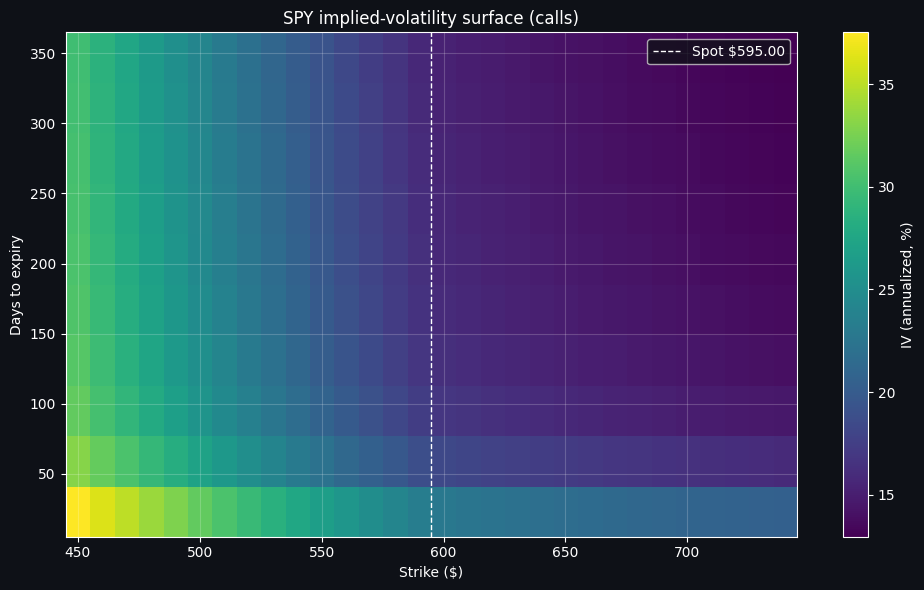

In [7]:
# Visualize the IV surface for calls.
surf = interpolated_surface(chain, side='call', n_strikes=30, n_dtes=10)
spot = float(chain['underlying_price'].iloc[0])

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(
    surf.iv * 100,
    aspect='auto',
    origin='lower',
    extent=[surf.strike_grid.min(), surf.strike_grid.max(), surf.dte_grid.min(), surf.dte_grid.max()],
    cmap='viridis',
)
ax.axvline(spot, color='white', linestyle='--', linewidth=1, label=f'Spot ${spot:.2f}')
ax.set_xlabel('Strike ($)')
ax.set_ylabel('Days to expiry')
ax.set_title('SPY implied-volatility surface (calls)')
ax.legend(loc='upper right')
fig.colorbar(im, ax=ax, label='IV (annualized, %)')
plt.tight_layout()
plt.show()


## 6. Skew, smile, term structure

Three orthogonal cuts of the same surface:

- **Smile** -- IV as a function of strike at one fixed expiry. Pure call/put BS would predict a flat line; observed equity-index option markets always show a downward skew (OTM puts richer than OTM calls).
- **Term structure** -- ATM IV across expiries. Reflects market expectations of how vol evolves over time, including event premia from earnings or macro announcements.
- **25-delta risk reversal** (`IV(25\Delta\,\text{call}) - IV(25\Delta\,\text{put})`) and **butterfly** (`(IV(25\Delta\,\text{call}) + IV(25\Delta\,\text{put}))/2 - \text{ATM}`). The 25-delta strikes are located by interpolating delta vs strike, rather than rounded to the nearest listed strike, so the metric is comparable across expiries with different listed grids.

The sticky-strike vs sticky-delta debate (how the smile reshapes after a spot move) is unresolved and varies by underlier; this dashboard reports the metrics, leaves the interpretation to the user.

In [8]:
sk = skew(chain)
print(sk.per_expiry.to_string(index=False))


    expiry  atm_iv    rr_25d   bf_25d     slope
2026-05-18  0.2292 -0.010876 0.002705 -0.308453
2026-05-25  0.2169 -0.015874 0.003790 -0.308403
2026-06-19  0.1894 -0.023892 0.005599 -0.308345
2026-08-16  0.1683 -0.032675 0.006910 -0.308403
2026-11-09  0.1607 -0.040731 0.007663 -0.308558
2027-05-13  0.1542 -0.049030 0.006953 -0.308488


## 7. Max pain -- what it is and what it isn't

Max-pain is the strike that minimizes the total dollar pain to option holders if the underlying pins exactly there at expiration:

$$\text{pain}(K) = 100 \cdot \left[\sum_{i \in \text{calls}} OI_i \max(K - K_i, 0) + \sum_{j \in \text{puts}} OI_j \max(K_j - K, 0)\right].$$

The factor of 100 is the standard contract multiplier, so the output is in dollars. Max pain is folk wisdom on options-trading desks ('stocks pin to max pain'). It is **not** a law of finance: the academic evidence for systematic pinning is mixed (Ni, Pearson & Poteshman 2005 find a small effect around monthly OPEX for some stocks; later studies find weaker or no effect once you control for delta-hedging flows). Treat it as a positioning indicator for the nearest expiry, not as a directional forecast.

In [9]:
pains = max_pain_all_expiries(chain)
for expiry, result in pains.items():
    print(f'{expiry.isoformat()}: max-pain strike = ${result.strike:8.2f}  total pain = ${result.dollar_pain/1e6:8.2f}M')


2026-05-18: max-pain strike = $  595.00  total pain = $  407.82M
2026-05-25: max-pain strike = $  600.00  total pain = $  357.43M
2026-06-19: max-pain strike = $  605.00  total pain = $ 1101.77M
2026-08-16: max-pain strike = $  595.00  total pain = $ 1133.21M
2026-11-09: max-pain strike = $  600.00  total pain = $  420.60M
2027-05-13: max-pain strike = $  590.00  total pain = $  375.18M


## 8. Gamma exposure (GEX)

Per-strike dollar GEX, under the SqueezeMetrics convention (dealers are short calls and long puts):

$$\text{GEX}_{\text{call}}(K) = +\gamma(K) \cdot OI_{\text{call}}(K) \cdot 100 \cdot S^2 \cdot 0.01,$$
$$\text{GEX}_{\text{put}}(K) = -\gamma(K) \cdot OI_{\text{put}}(K) \cdot 100 \cdot S^2 \cdot 0.01.$$

Units are dollars of gamma exposure per **1% move** in the underlying. The sign convention is itself a methodology choice -- different vendors flip the signs and the interpretation flips with them. The SqueezeMetrics convention reads as follows: **positive total GEX = long-gamma regime, dampened realized vol** (dealer hedges sell into rallies, buy into dips); **negative total GEX = short-gamma, amplified vol** (dealers chase price). The **gamma flip level** is the strike at which cumulative GEX crosses zero walking down from the highest strike; spot trading below the flip is the canonical short-gamma regime warning.

What the model leaves out: dealer positioning is **assumed**, not measured. The convention 'dealers short calls, long puts' fits retail-flow-dominated underliers like SPY reasonably well, but it can be wildly wrong for individual single names where dealers run idiosyncratic books.

In [10]:
gex_result = gamma_exposure(chain)
print(f'Total GEX (all strikes, all expiries): {gex_result.total_gex/1e6:+.2f} $MM per 1% move')
print(f'Gamma flip strike: ${gex_result.gamma_flip_strike:.2f}' if gex_result.gamma_flip_strike else 'No gamma flip found')
print(f'Underlying spot:   ${gex_result.underlying_price:.2f}')


Total GEX (all strikes, all expiries): +110.72 $MM per 1% move
No gamma flip found
Underlying spot:   $595.00


## 9. The risk-neutral implied probability density (Breeden-Litzenberger)

Breeden & Litzenberger (1978) showed that the risk-neutral density of the underlying at expiry $T$ equals the discounted second derivative of the call price with respect to strike:

$$f^*(K) = e^{rT} \frac{\partial^2 C}{\partial K^2}.$$

In practice we observe call prices on a discrete strike grid, so we fit a smoothing spline through the call-price curve, take its analytical second derivative, normalise to integrate to one over the strike grid, and warn when the resulting density is non-positive at any point. A non-positive density indicates a butterfly arbitrage in the input price quotes (a violation of convexity in strike), usually from stale or wide-bid-ask mid prices.

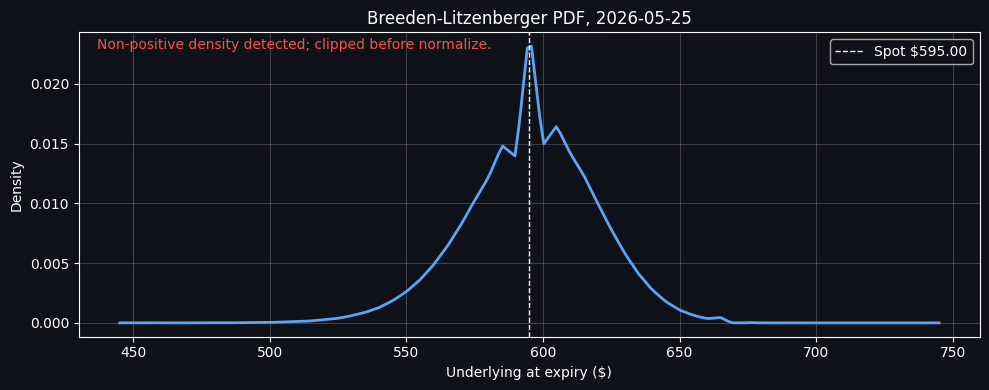

In [11]:
expiry = sorted(chain['expiry'].unique())[1]  # second-nearest expiry
expiry_d = expiry.date() if hasattr(expiry, 'date') else expiry
pdf = implied_pdf_for_expiry(chain, expiry_d, r=0.04)
if pdf is None:
    print(f'Not enough call quotes for {expiry_d.isoformat()}')
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(pdf.strikes, pdf.density, color='#5BA3F5', linewidth=2)
    ax.axvline(spot, color='white', linestyle='--', linewidth=1, label=f'Spot ${spot:.2f}')
    ax.set_xlabel('Underlying at expiry ($)')
    ax.set_ylabel('Density')
    ax.set_title(f'Breeden-Litzenberger PDF, {expiry_d.isoformat()}')
    ax.legend()
    if pdf.has_negative_density:
        ax.text(0.02, 0.98, 'Non-positive density detected; clipped before normalize.',
                transform=ax.transAxes, ha='left', va='top', color='#F85149')
    plt.tight_layout()
    plt.show()


## 10. Cross-source validation

The dashboard supports three providers (yfinance, Tradier, Polygon) and the aggregator returns a per-provider chain plus a consensus chain with median IV per `(expiry, strike, type)`. The `CrossSourceValidator` reports, for every contract present in at least two providers: the spread of provider IVs, the spread of provider mids, the spread of OI, and the residual between the median provider IV and the IV recomputed from the median mid via this package's hand-rolled solver.

On illiquid strikes the disagreement between providers is often material. The calibration residual is a useful sanity check: if our solver consistently disagrees with the provider IVs by some characteristic gap, that points to a different normalising assumption (typically dividend yield handling or risk-free rate source) rather than a solver bug.

## 11. Limitations

A few caveats worth flagging before reading too much into any single number.

- **European-option assumption on American equity options.** US-listed equity options are American-style. We use Black-Scholes-Merton (European) throughout, which is a reasonable approximation for non-dividend-paying names and for near-the-money strikes, but breaks down for deep ITM puts on dividend payers and around ex-dividend dates more generally. A full pricer would need the binomial / Bjerksund-Stensland approximation; that is out of scope for this repo.
- **Continuous dividend yield from trailing data.** We take `yfinance.Ticker.info['dividendYield']` (annualised) and treat it as the continuous $q$. This is fine for steady payers and breaks around special dividends, recent initiations, and cuts.
- **Risk-free rate is a single point.** The dashboard uses one rate (yfinance `^IRX` divided by 100; FRED `DGS3MO` if available; 0.04 otherwise) rather than a per-expiry rate from the OIS curve. The error is in the 1-3 bp range for typical SPY-like names and bigger for very long-dated options.
- **GEX dealer sign convention is an assumption.** SqueezeMetrics has dealers short calls and long puts. That fits retail-flow-dominated underliers; it can be wildly wrong on single names where dealers run idiosyncratic books.
- **Earnings-crush formula deviation.** The BUILD_PROMPT-spec formula $\sqrt{(IV_{pre}^2 T_{pre} - IV_{post}^2 T_{post}) / T_{event}}$ evaluates to $\sqrt{\text{negative}}$ for any realistic post-event vol crush. We implement the standard two-equation decomposition instead, where post-event steady-state vol is solved first and event variance backed out. See the docstring in `src/ord/analytics/earnings_crush.py`.
- **Breeden-Litzenberger spline sensitivity.** The PDF is very sensitive to the smoothing parameter on noisy quote curves. The dashboard exposes a smoothing slider; the methodology default is `s = 0` (interpolating spline) which is correct for clean prices but amplifies noise on wide-bid-ask names.
- **yfinance data quality is uneven.** Vendor-stale fields (zero OI, NaN IV) are common on weeklies and deep-OTM strikes. The package leaves them `None` rather than imputing; analytics that need them (max-pain, GEX) effectively skip those rows.

## 12. References

- Black, F. & Scholes, M. (1973). The pricing of options and corporate liabilities. *Journal of Political Economy*, 81(3), 637-654.
- Breeden, D. T. & Litzenberger, R. H. (1978). Prices of state-contingent claims implicit in option prices. *Journal of Business*, 51(4), 621-651.
- Manaster, S. & Koehler, G. (1982). The calculation of implied variances from the Black-Scholes model. *Journal of Finance*, 37(1), 227-230.
- Merton, R. C. (1973). Theory of rational option pricing. *Bell Journal of Economics and Management Science*, 4(1), 141-183.
- Ni, S. X., Pearson, N. D. & Poteshman, A. M. (2005). Stock price clustering on option expiration dates. *Journal of Financial Economics*, 78(1), 49-87.
- SqueezeMetrics (2017). *The implied order book*. White paper on dealer gamma exposure and the gamma-flip framework.
- Sinclair, E. (2013). *Volatility Trading*, 2nd ed. Wiley. Chapter 11 covers the standard term-structure decomposition used in the earnings-crush analytic.

---

## Live refresh (optional)

The cells above use the dated SPY fixture so this notebook is reproducible. Uncomment the cell below to re-run everything against today's live chain via the same `ChainAggregator` the dashboard uses.

In [12]:
# from ord.data.aggregator import ChainAggregator
# from ord.data.yfinance_provider import YFinanceProvider
# aggregator = ChainAggregator([YFinanceProvider()])
# bundle = aggregator.fetch('SPY', max_expiries=4)
# chain = bundle.consensus
# print(f'Live SPY chain: {len(chain)} rows across {chain["expiry"].nunique()} expiries.')
